In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yaml
import numpy as np
import pandas as pd

from spiir.distribution import load_priors_from_config, load_transforms_from_config

In [3]:
with open("../core/config/sigmasq.yaml") as file:
    config = yaml.safe_load(file)
config

{'seed': 21,
 'distributions': [{'variable': 'mass_1',
   'distribution': 'normal',
   'loc': 7,
   'scale': 2},
  {'variable': 'mass_2', 'distribution': 'normal', 'loc': 6, 'scale': 1},
  {'variable': 'phase',
   'distribution': 'uniform',
   'low': 0.0,
   'high': 3.141592653589793},
  {'variable': 'chi_1',
   'distribution': 'uniform',
   'seed': 20,
   'low': 0.0,
   'high': 0.88},
  {'variable': 'chi_2', 'distribution': 'uniform', 'low': 0.0, 'high': 0.88},
  {'variable': 'theta_1', 'distribution': 'sin_angle', 'package': 'pycbc'},
  {'variable': 'theta_2', 'distribution': 'sin_angle', 'package': 'pycbc'},
  {'variable': 'theta_jn', 'distribution': 'sin_angle', 'package': 'pycbc'},
  {'variable': 'phi_12',
   'distribution': 'uniform',
   'seed': 20,
   'low': 0.0,
   'high': 3.141592653589793},
  {'variable': 'phi_jl',
   'distribution': 'uniform',
   'low': 0.0,
   'high': 3.141592653589793}],
 'transforms': [{'transform': 'abs',
   'package': 'numpy',
   'variables': 'mass_1'},

In [4]:
transforms = load_transforms_from_config(config)
transform = transforms[0]
transforms

[NumPyTransform(variables=('mass_1',), transform='abs', kwargs={}),
 NumPyTransform(variables=('mass_2',), transform='abs', kwargs={}),
 SPIIRTransform(transform='sigmasq', kwargs={'psd': '/home/dawn/daniel/ozgrav/spiir-data/share/data/psd/H1L1V1-REF_PSD-1257382107-1257388107.xml', 'ifos': ['H1', 'L1', 'V1']})]

In [5]:
priors = load_priors_from_config(config)
priors

JointDistribution(
  distributions=(
    NumPyDistribution(variable='mass_1', distribution='normal', kwargs={'loc': 7, 'scale': 2}),
    NumPyDistribution(variable='mass_2', distribution='normal', kwargs={'loc': 6, 'scale': 1}),
    NumPyDistribution(variable='phase', distribution='uniform', kwargs={'low': 0.0, 'high': 3.141592653589793}),
    NumPyDistribution(variable='chi_1', distribution='uniform', kwargs={'low': 0.0, 'high': 0.88}),
    NumPyDistribution(variable='chi_2', distribution='uniform', kwargs={'low': 0.0, 'high': 0.88}),
    PyCBCDistribution(variable='theta_1', distribution='sin_angle', kwargs={}),
    PyCBCDistribution(variable='theta_2', distribution='sin_angle', kwargs={}),
    PyCBCDistribution(variable='theta_jn', distribution='sin_angle', kwargs={}),
    NumPyDistribution(variable='phi_12', distribution='uniform', kwargs={'low': 0.0, 'high': 3.141592653589793}),
    NumPyDistribution(variable='phi_jl', distribution='uniform', kwargs={'low': 0.0, 'high': 3.14159265

In [6]:
samples = priors.draw(1000)
samples

SigmaSqTransform.apply method in incomplete testing state!
Simulating CBC inspiral waveforms to compute sigmasq: 100%|██████████| 1000/1000 [00:12<00:00, 83.15it/s]
SigmaSqTransform.apply method in incomplete testing state!
Simulating CBC inspiral waveforms to compute sigmasq: 100%|██████████| 1000/1000 [00:12<00:00, 79.91it/s]
SigmaSqTransform.apply method in incomplete testing state!
Simulating CBC inspiral waveforms to compute sigmasq: 100%|██████████| 1000/1000 [00:12<00:00, 80.30it/s]


,mass_1,mass_2,phase,chi_1,chi_2,theta_1,theta_2,theta_jn,phi_12,phi_jl,sigmasq
0,7.717547,6.358773,2.453953,0.246467,0.687383,2.241153,0.987328,2.110593,0.879885,2.453953,11.870575
1,10.373227,7.686614,0.279909,0.459895,0.078406,1.725751,1.657227,1.494105,1.641823,0.279909,10.365591
2,8.168127,6.584064,0.619499,0.563356,0.173530,1.024531,0.817233,0.855078,2.011175,0.619499,15.904620
3,8.276572,6.638286,2.111336,0.238030,0.591412,0.554280,1.488718,1.961876,0.849766,2.111336,10.417163
4,11.366428,8.183214,0.696413,0.715709,0.195074,1.626713,2.461840,1.914498,2.555074,0.696413,13.804309
...,...,...,...,...,...,...,...,...,...,...,...
995,7.601687,6.300844,0.278367,0.361375,0.077974,2.334632,1.349544,0.912934,1.290105,0.278367,13.138722
996,5.500042,5.250021,2.023295,0.562762,0.566751,1.361777,1.720216,2.489618,2.009055,2.023295,13.349447
997,9.092780,7.046390,2.475362,0.063252,0.693380,0.549133,1.910820,0.789389,0.225808,2.475362,18.818263
998,5.478319,5.239160,2.408167,0.388059,0.674558,2.834002,1.844799,0.324445,1.385369,2.408167,16.941112


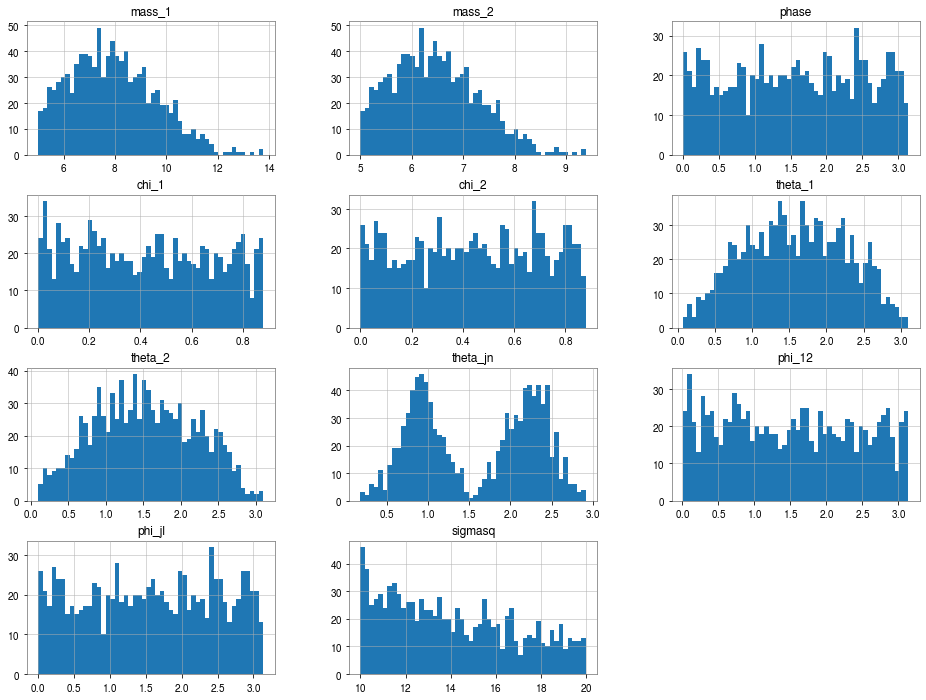

In [7]:
samples.hist(bins=50, figsize=(16,12));